In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  
# data (as pandas dataframes) 
X = air_quality.data.features 
y = air_quality.data.targets 
  
# metadata 
print(air_quality.metadata) 
  
# variable information 
print(air_quality.variables) 

{'uci_id': 360, 'name': 'Air Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/360/air+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/360/data.csv', 'abstract': 'Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. ', 'area': 'Computer Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 9358, 'num_features': 15, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C59K5F', 'creators': ['Saverio Vito'], 'intro_paper': {'ID': 420, 'type': 'NATIVE', 'title': 'On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario', 'authors': 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# Replace -200 with NaN for missing values
X = X.replace(-200, pd.NA)

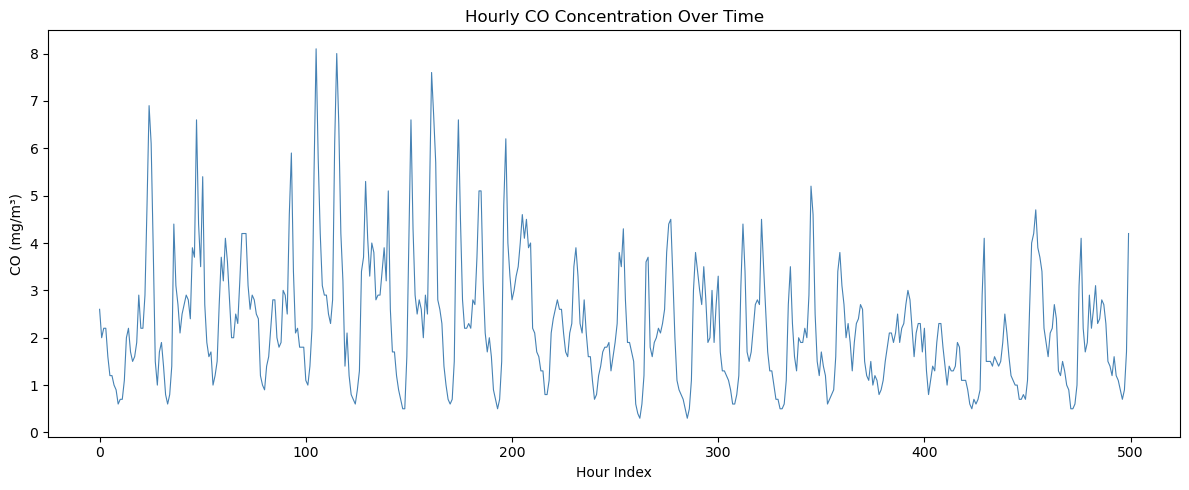

In [5]:
# CO concentration over time
plt.figure(figsize=(12, 5))
plt.plot(X['CO(GT)'].dropna().values[:500], color='steelblue', linewidth=0.8)
plt.title('Hourly CO Concentration Over Time')
plt.xlabel('Hour Index')
plt.ylabel('CO (mg/m³)')
plt.tight_layout()
plt.show()

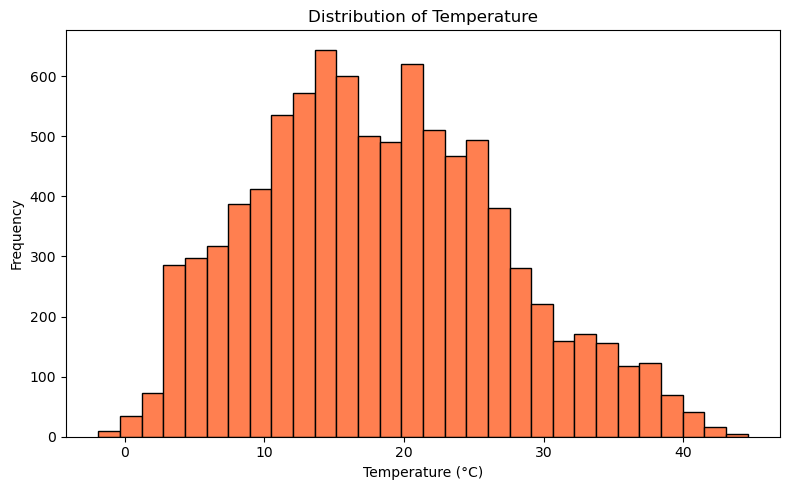

In [7]:
# How frequently different temperature ranges were recorded across the year
plt.figure(figsize=(8, 5))
plt.hist(X['T'].dropna(), bins=30, color='coral', edgecolor='black')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

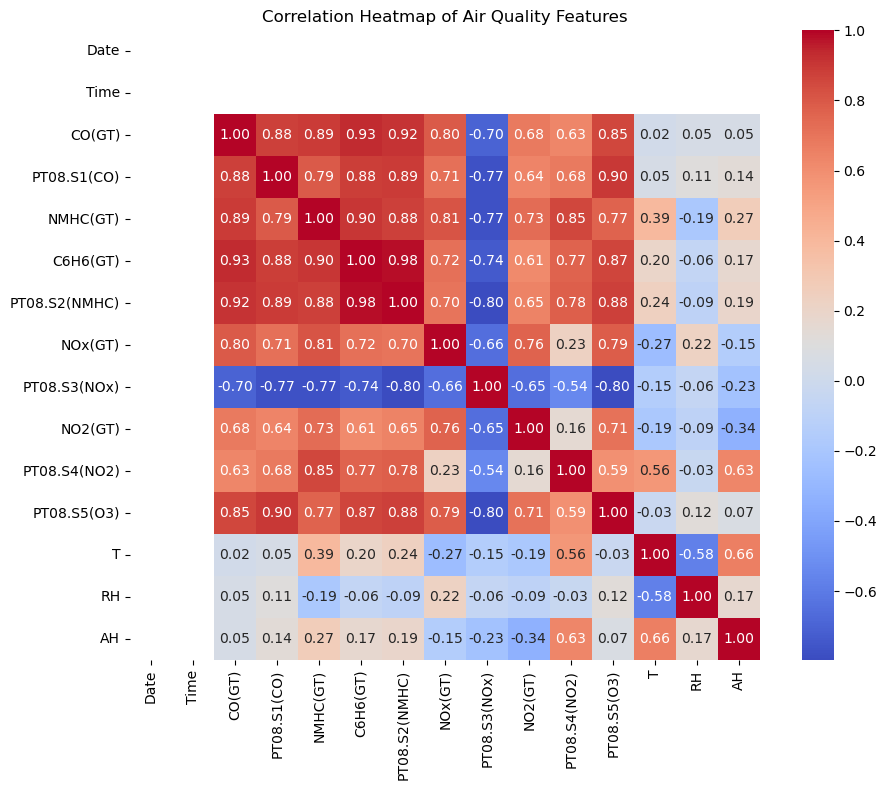

In [13]:
# Sensor readings and pollutants that are related to each other

# Convert all columns to numeric (non-numeric values become NaN)
X_numeric = X.apply(pd.to_numeric, errors='coerce')

# Replace the -200 missing marker with NaN
X_numeric = X_numeric.replace(-200, np.nan)
plt.figure(figsize=(10, 8))
corr = X_numeric.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Air Quality Features')
plt.tight_layout()
plt.show()

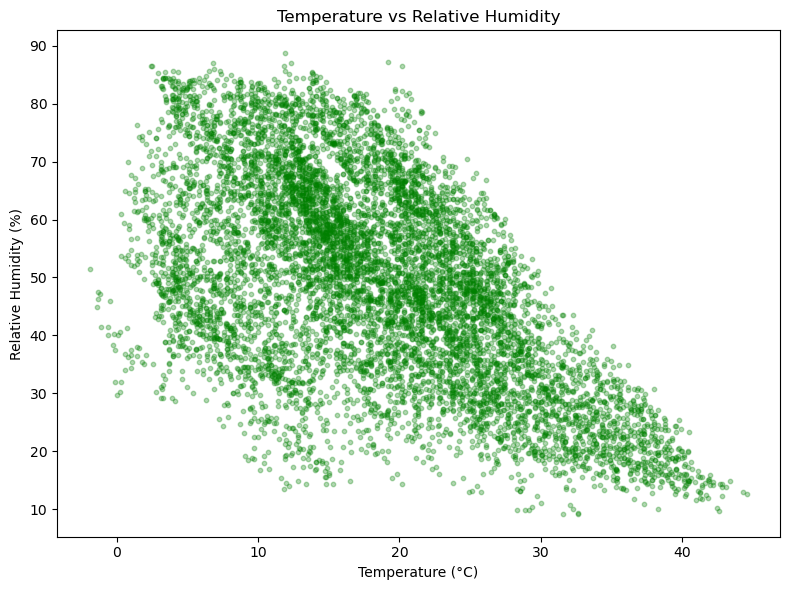

In [9]:
# Relationships between environment variables
plt.figure(figsize=(8, 6))
plt.scatter(X['T'].dropna(), X['RH'].dropna()[:len(X['T'].dropna())],
            alpha=0.3, s=10, color='green')
plt.title('Temperature vs Relative Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.tight_layout()
plt.show()